In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('house_prices.csv')
print(df.shape)
print(df.head())
print(df.isnull().sum().sort_values(ascending=False)[:15])

(2930, 82)
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice

In [2]:
# Drop columns with too many missing values
df.drop(columns=[c for c in ['Alley', 'Pool QC', 'Fence', 'Misc Feature'] if c in df.columns], inplace=True)

# Fill numeric nulls with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical nulls with mode
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# Encode categorical columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.isnull().sum().sum())  # Should be 0

0


In [3]:
# Correlation with target
corr = df.corr()['SalePrice'].sort_values(ascending=False)
print(corr[:15])

# Pick top features
top_features = corr[1:11].index.tolist()  # Top 10 features
print("Selected Features:", top_features)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647812
Garage Area       0.640381
Total Bsmt SF     0.632164
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.508882
Mas Vnr Area      0.502196
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432862
Name: SalePrice, dtype: float64
Selected Features: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath', 'Year Remod/Add', 'Garage Yr Blt']


In [4]:
X = df[top_features]
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (2344, 10), Test: (586, 10)


In [5]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


Linear Regression
  RMSE: $39,299
  R² Score: 0.8074

Random Forest
  RMSE: $32,087
  R² Score: 0.8716


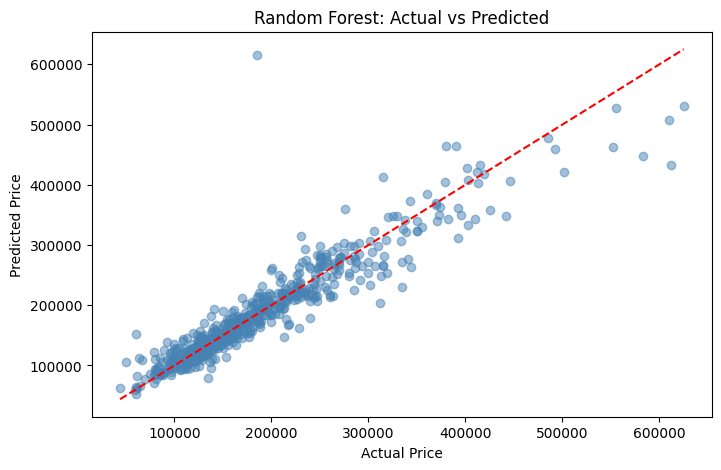

In [6]:
def evaluate(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  R² Score: {r2:.4f}")

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)

# Visualize: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted')
plt.savefig('model_eval.png')
plt.show()

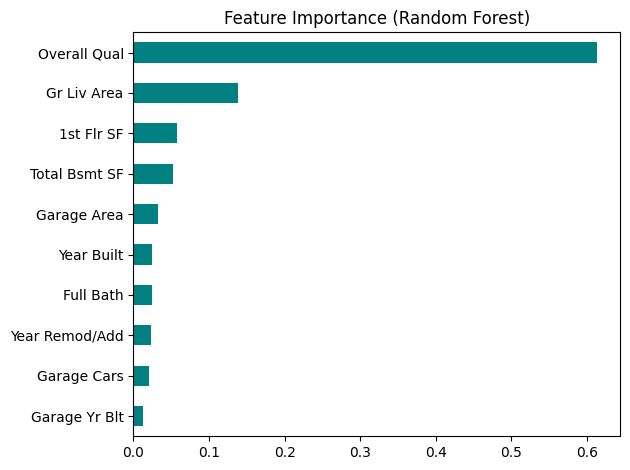

In [7]:
importances = pd.Series(rf.feature_importances_, index=top_features)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()